# Walmart : prédiction des ventes hebdomadaires
Ce notebook montre l'analyse exploratoire des données (EDA), le prétraitement, l'apprentissage non supervisé (PCA & K-Means) et l'apprentissage supervisé (Linéaire, Ridge, Lasso) pour prédire les ventes hebdomadaires des magasins.

## 1. Importation des bibliothèques


In [9]:
lang = 'fr'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')


## 2. Chargement du jeu de données et Analyse Exploratoire (EDA)
Chargeons le jeu de données et affichons les premières lignes et statistiques générales.


In [10]:
# Load the dataset
df = pd.read_csv('Walmart_Store_sales.csv')
display(df.head())
print("Shape of dataset:", df.shape)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


Shape of dataset: (150, 8)


In [11]:
# Basic statistics
display(df.describe(include='all'))
print("Missing values:\n", df.isnull().sum())


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,132,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
unique,NaN,85,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,19-10-2012,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
mean,9.866667,NaN,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,NaN,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,NaN,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,NaN,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,NaN,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,NaN,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000


Missing values:
 Store            0
Date            18
Weekly_Sales    14
Holiday_Flag    12
Temperature     18
Fuel_Price      14
CPI             12
Unemployment    15
dtype: int64


### Visualisation des valeurs manquantes
Nous pouvons visualiser les valeurs manquantes pour mieux comprendre la complétion des données.


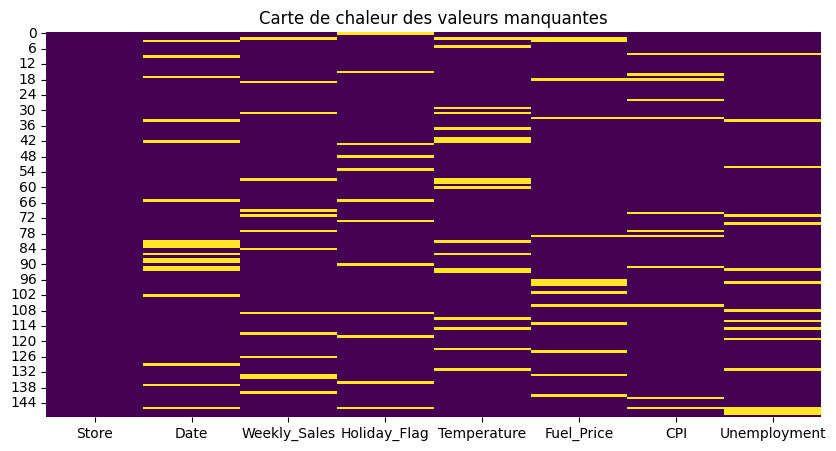

In [12]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing values heatmap' if lang == 'en' else 'Carte de chaleur des valeurs manquantes')
plt.show()


### Distribution de la variable cible (`Weekly_Sales`)


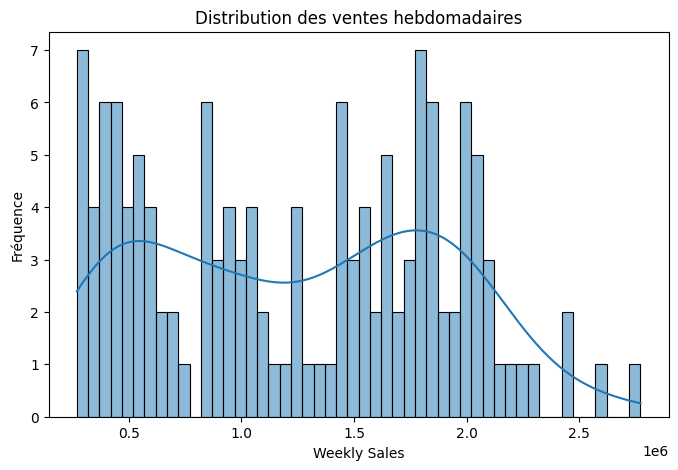

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=50, kde=True)
plt.title('Distribution of Weekly Sales' if lang == 'en' else 'Distribution des ventes hebdomadaires')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency' if lang == 'en' else 'Fréquence')
plt.show()


## 3. Prétraitement (Pandas)
- Supprimer les lignes où `Weekly_Sales` est manquant.
- Créer `Year`, `Month`, `Day` et `DayOfWeek` depuis `Date`.
- Supprimer les valeurs aberrantes pour les variables numériques.


In [14]:
# Drop missing target values
df = df.dropna(subset=['Weekly_Sales'])

# Create datetime features
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df = df.drop('Date', axis=1)

# Remove outliers ([mean - 3*std, mean + 3*std])
num_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
for col in num_features:
    mean = df[col].mean()
    std = df[col].std()
    df = df[(df[col] >= mean - 3*std) & (df[col] <= mean + 3*std) | df[col].isnull()]

print("Dimensions après prétraitement pandas:", df.shape)


Dimensions après prétraitement pandas: (131, 11)


## 4. Apprentissage Non Supervisé
### Analyse en Composantes Principales (PCA)


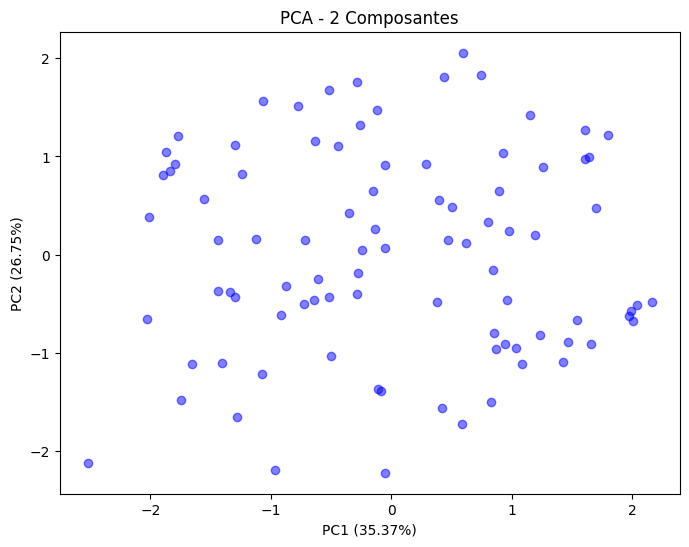

In [15]:
# Prepare data for PCA (only numerical features)
X_num = df[num_features].dropna()
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_num)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, c='b')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA - 2 Components" if lang == 'en' else "PCA - 2 Composantes")
plt.show()


### Clustering K-Means
Appliquons K-Means pour trouver des groupes potentiels dans les données.


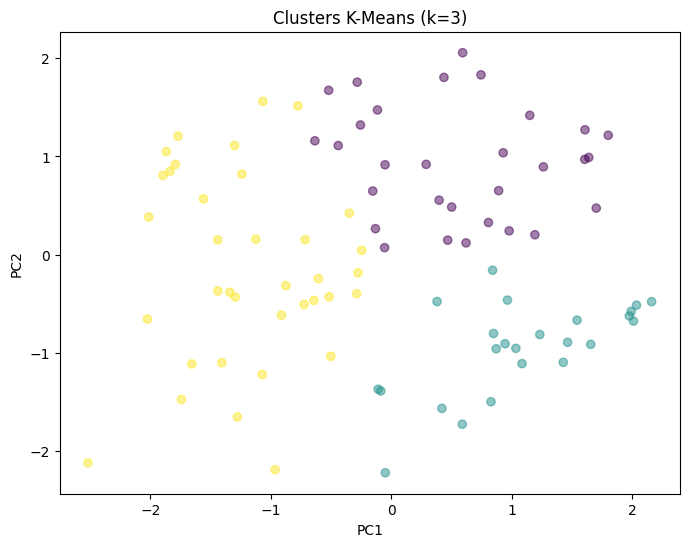

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (k=3)" if lang == 'en' else "Clusters K-Means (k=3)")
plt.show()


## 5. Apprentissage Supervisé - Pipeline de prétraitement
Préparation des pipelines Scikit-Learn pour gérer les valeurs manquantes et la mise à l'échelle/encodage.


In [17]:
# Separate target and features
target_name = 'Weekly_Sales'
Y = df[target_name]
X = df.drop(target_name, axis=1)

# Split into train/test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Define pipelines
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']
categorical_features = ['Store', 'Holiday_Flag']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


## 6. Modèle de Base : Régression Linéaire
Entraînement et évaluation d'un modèle de Régression Linéaire standard.


In [18]:
# Train Baseline
baseline = LinearRegression()
baseline.fit(X_train_processed, Y_train)

# Predictions
Y_train_pred = baseline.predict(X_train_processed)
Y_test_pred = baseline.predict(X_test_processed)

# Evaluation
print("--- Baseline Model ---")
print("Train R2 Score:", r2_score(Y_train, Y_train_pred))
print("Test R2 Score:", r2_score(Y_test, Y_test_pred))

# Get feature importance
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
coefs = pd.DataFrame({'Feature': feature_names, 'Coefficient': baseline.coef_}).sort_values(by='Coefficient', ascending=False)
display(coefs.head())
display(coefs.tail())


--- Baseline Model ---
Train R2 Score: 0.9771347825598194
Test R2 Score: 0.8908899782260357


,Feature,Coefficient
19,Store_14.0,579821.243035
10,Store_4.0,487598.013632
25,Store_20.0,462673.103249
18,Store_13.0,371837.719598
8,Store_2.0,357742.870621


,Feature,Coefficient
13,Store_7.0,-9.942654e+05
15,Store_9.0,-1.142852e+06
21,Store_16.0,-1.176968e+06
9,Store_3.0,-1.202338e+06
11,Store_5.0,-1.360104e+06


## 7. Modèles Régularisés : Ridge & Lasso
Utilisation de GridSearchCV pour trouver la force de régularisation optimale.


In [19]:
# GridSearchCV for Ridge
ridge = Ridge()
params_ridge = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
grid_ridge = GridSearchCV(ridge, params_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train_processed, Y_train)

print("Best alpha for Ridge:", grid_ridge.best_params_['alpha'])
print("Train R2 (Ridge):", r2_score(Y_train, grid_ridge.predict(X_train_processed)))
print("Test R2 (Ridge):", r2_score(Y_test, grid_ridge.predict(X_test_processed)))


Best alpha for Ridge: 0.01
Train R2 (Ridge): 0.9771121704497737
Test R2 (Ridge): 0.8920427912535305


In [20]:
# GridSearchCV for Lasso
lasso = Lasso(max_iter=10000)
params_lasso = {'alpha': [1, 10, 100, 500, 1000, 2000]}
grid_lasso = GridSearchCV(lasso, params_lasso, cv=5, scoring='r2')
grid_lasso.fit(X_train_processed, Y_train)

print("Best alpha for Lasso:", grid_lasso.best_params_['alpha'])
print("Train R2 (Lasso):", r2_score(Y_train, grid_lasso.predict(X_train_processed)))
print("Test R2 (Lasso):", r2_score(Y_test, grid_lasso.predict(X_test_processed)))


Best alpha for Lasso: 500
Train R2 (Lasso): 0.976698833962678
Test R2 (Lasso): 0.8974505760623164
